In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import average_precision_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib
import shap

In [6]:
df=pd.read_csv("/Users/shyamchauhan/Desktop/home/codes/fraud-detection/dataset/creditcard.csv")

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.shape

(284807, 31)

In [9]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

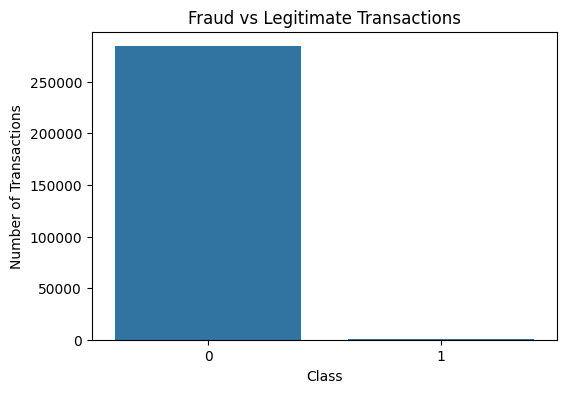

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [15]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# EDA(Exploratory Data Analysis)

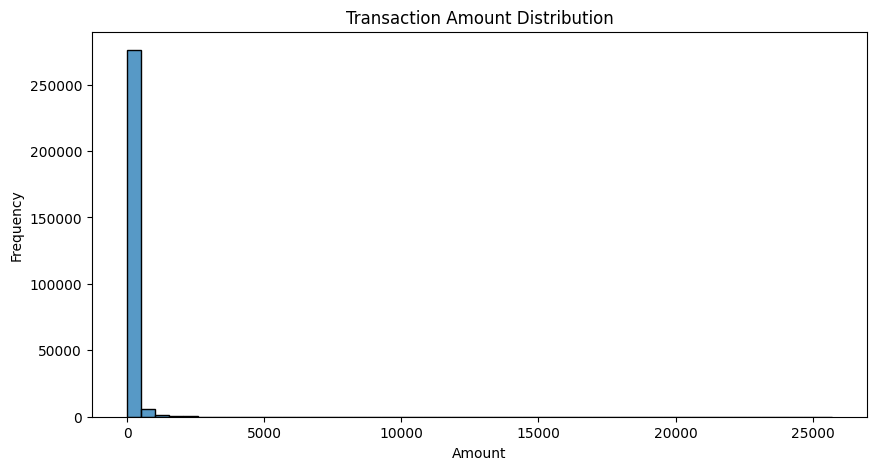

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

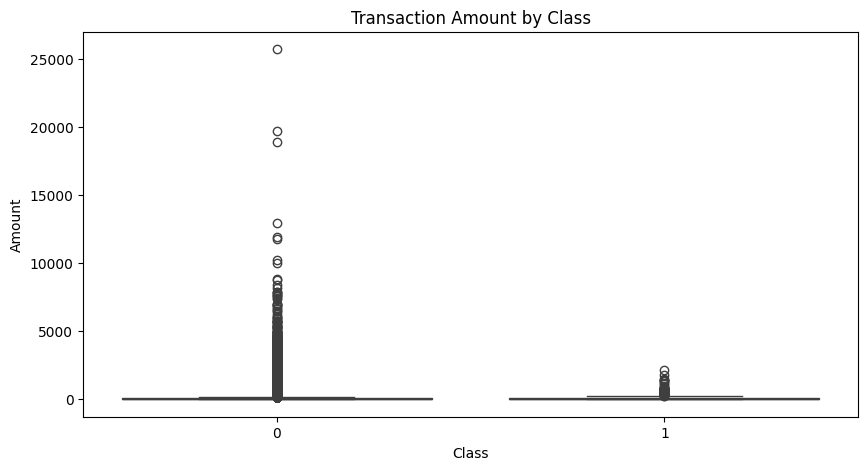

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")

plt.show()

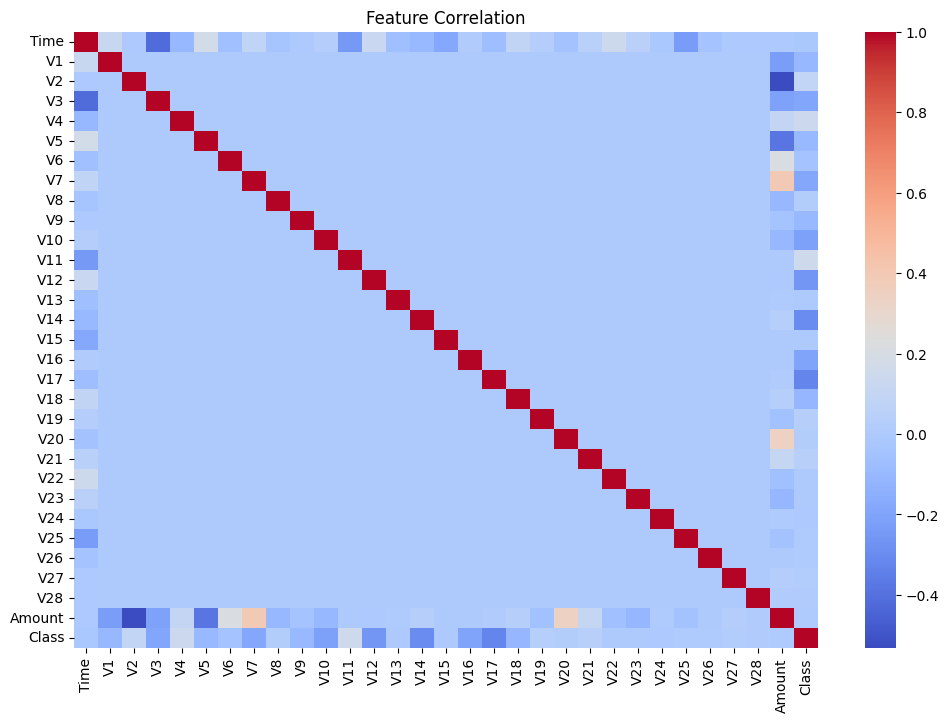

In [19]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation")
# Which features are associated with fraud?
plt.show()

# Data preprocessing

In [20]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
scaler = StandardScaler()

In [23]:
X_train_scaled = scaler.fit_transform(X_train)

In [24]:
X_test_scaled = scaler.transform(X_test)

In [25]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [26]:
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [27]:
y_pred = lr_model.predict(X_test_scaled)

In [28]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [29]:
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

In [30]:
y_prob

array([0.00569098, 0.06755242, 0.00011903, ..., 0.00026008, 0.00375493,
       0.08229136])

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



### Precision : Out of transactions predicted as fraud, how many were actually fraud?
### Recall : Out of all actual fraud transactions, how many did we detect?
### F1-score : Balance between precision and recall.

In [32]:
pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.7189705771419241


In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [34]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [35]:
rf_pred = rf_model.predict(X_test)

In [36]:
rf_pred

array([0, 0, 0, ..., 0, 0, 0])

In [37]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [38]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.78      0.83        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [39]:
rf_pr_auc = average_precision_score(y_test, rf_prob)

print("Random Forest PR-AUC:", rf_pr_auc)

Random Forest PR-AUC: 0.8497065844250361


In [40]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [41]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [42]:
xgb_pred = xgb_model.predict(X_test)

In [43]:
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [44]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [45]:
xgb_pr_auc = average_precision_score(y_test, xgb_prob)

print("XGBoost PR-AUC:", xgb_pr_auc)

XGBoost PR-AUC: 0.8787012021759681


In [46]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "PR-AUC": [
        pr_auc,
        rf_pr_auc,
        xgb_pr_auc
    ]
})
# PR-AUC means precision recall area under the curve.This is evaluation metric used when there is classification models used and especially when there is highly imbalanced data.
results

,Model,PR-AUC
0,Logistic Regression,0.718971
1,Random Forest,0.849707
2,XGBoost,0.878701


## Here we have compared Logistic Regression, Random Forest, and XGBoost using PR-AUC because the dataset is highly imbalanced. I selected the best-performing model based on fraud detection performance rather than accuracy alone.

## 20. Handle class imbalance properly
#### SMOTE creates synthetic minority-class samples by combining existing minority samples,because minority class haas less samples the model would be biased towards majority class ie.non fraud class.
#### It helps balance the dataset so the model learns fraud patterns better.

In [47]:
smote = SMOTE(random_state=42)

In [48]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

/Users/shyamchauhan/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [49]:
y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

## Do not apply SMOTE before train-test splitting.Otherwise, synthetic information can leak into the test set.

In [50]:
def get_risk_level(score):
    if score < 30:
        return "LOW"
    elif score < 70:
        return "MEDIUM"
    else:
        return "HIGH"

In [51]:
joblib.dump(xgb_model, "../saved_models/fraud_model.pkl")

['../saved_models/fraud_model.pkl']

In [52]:
joblib.dump(scaler, "../saved_models/scaler.pkl")

['../saved_models/scaler.pkl']

In [53]:
joblib.dump(X.columns.tolist(), "../saved_models/features.pkl")

['../saved_models/features.pkl']

In [54]:
xgb_model=joblib.load("/Users/shyamchauhan/Desktop/home/codes/fraud-detection/saved_models/saved_xgb_model.pkl")
explainer = shap.TreeExplainer(xgb_model)

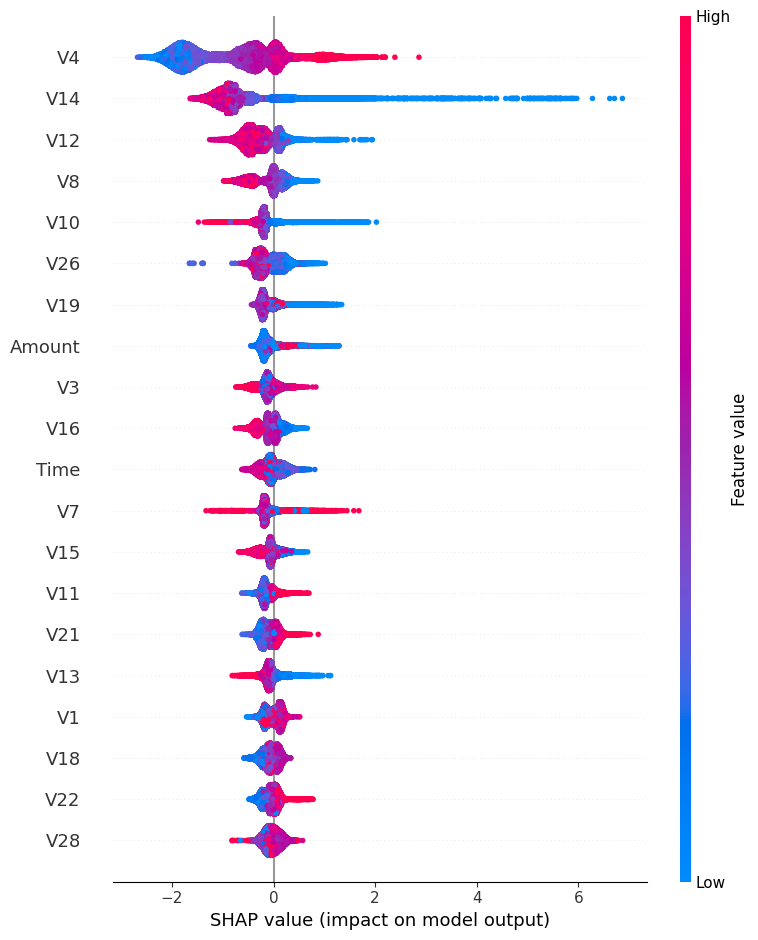

In [55]:
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)